# تمرین سوم

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix

from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB, MultinomialNB


## بخش الف

مثل تمرین های قبل ابتدا دیتاست رو میخونیم

In [2]:
raw_data = pd.read_csv("./anti-malware .csv").set_axis(labels=list(range(312)), axis=1)
raw_data

,0,1,2,3,4,5,6,7,8,9,...,302,303,304,305,306,307,308,309,310,311
0,0,0,0,0,0,2,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,2,2,0,10,0,4,1,0,0,1,...,0,0,0,0,0,0,0,0,0,1
2,5,2,2,96,2,15,3,116,2,1,...,0,0,0,0,0,0,0,0,0,1
3,9,13,5,662,37,0,0,405,0,1,...,0,0,0,0,0,0,0,0,0,1
4,3,2,2,94,3,17,4,116,2,1,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11256,204,41,109,2680,77,102,24,148,0,12,...,0,0,0,0,0,0,0,0,0,1
11257,197,39,107,2525,73,135,24,148,0,12,...,0,0,0,0,0,0,0,0,0,1
11258,198,39,109,2534,72,162,22,188,0,11,...,0,0,0,0,0,0,0,0,0,1
11259,13,0,3,481,29,0,101,171,10,5,...,0,0,0,0,0,0,0,0,0,1


تعداد داده های گم شده اون رو چاپ میکنیم که برابر 0 است و هیچ داده گم شده ای نداریم

In [3]:
print(raw_data.isna().sum())

0      0
1      0
2      0
3      0
4      0
      ..
307    0
308    0
309    0
310    0
311    0
Length: 312, dtype: int64


تمام داده ها رو بر اساس مینیمم و ماکسیمم در بازه 0 و 1 نرمال میکنیم

In [4]:
num_cols = list(range(312))
min_max_scaler = MinMaxScaler()
x = raw_data[num_cols].values
x_scaled = min_max_scaler.fit_transform(x)

normalized = pd.DataFrame(x_scaled, columns=num_cols, index=raw_data.index)
raw_data[num_cols] = normalized
raw_data

,0,1,2,3,4,5,6,7,8,9,...,302,303,304,305,306,307,308,309,310,311
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000010,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0.000004,0.000400,0.000000,0.000019,0.000000,0.000021,0.000019,0.000000,0.000000,0.000125,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,0.000011,0.000400,0.000065,0.000184,0.000029,0.000078,0.000057,0.004241,0.006410,0.000125,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.000019,0.002601,0.000163,0.001270,0.000534,0.000000,0.000000,0.014809,0.000000,0.000125,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0.000006,0.000400,0.000065,0.000180,0.000043,0.000089,0.000076,0.004241,0.006410,0.000125,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11256,0.000432,0.008202,0.003564,0.005142,0.001112,0.000534,0.000455,0.005412,0.000000,0.001494,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
11257,0.000417,0.007802,0.003499,0.004845,0.001054,0.000706,0.000455,0.005412,0.000000,0.001494,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
11258,0.000419,0.007802,0.003564,0.004862,0.001040,0.000848,0.000417,0.006874,0.000000,0.001370,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
11259,0.000028,0.000000,0.000098,0.000923,0.000419,0.000000,0.001914,0.006253,0.032051,0.000623,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


داده ها رو به دو دسته داده های تمرین(80 درصد) و داده تست(20 درصد) تقسیم میکنیم

In [5]:
Y = np.array(raw_data.pop(311))
X = np.array(raw_data)
print(X.shape, Y.shape)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2)
print(X_test.shape, Y_test.shape)

(11261, 311) (11261,)
(2253, 311) (2253,)


## بخش ب

یک مدل رگرسیون رجیستیکی با هدف شناسایی بدافزار آموزش میدهیم و ماتریس درهمریختگی آن را چاپ میکنیم

این ماتریس توانسته ۱۰۰ نمونه از کلاس ۰ و ۱۷۰۰ نمونه از کلاس ۱ را به درستی تشخیص دهد. همچنین ۳۹۰ نمونه از کلاس ۰ و ۳۶ نمونه از کلاس ۱ را به اشتباه پیش‌بینی کرده است. این مدل تفکیک بهتری بین هر دو کلاس انجام داده است.

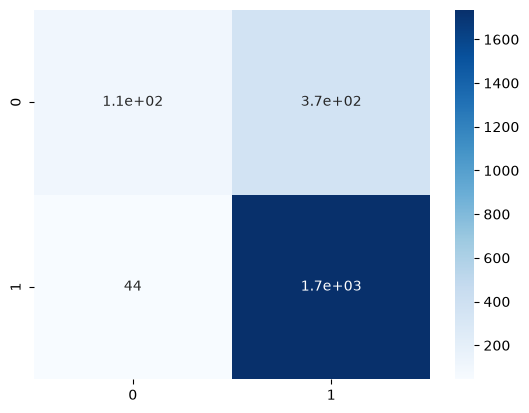

0.8175765645805593


In [6]:
lr = LogisticRegression()

lr.fit(X_train, Y_train)
acc = accuracy_score(Y_test, lr.predict(X_test))

cm = confusion_matrix(Y_test, lr.predict(X_test))
sns.heatmap(cm, annot=True, cmap="Blues")
plt.show()
print(acc)

## بخش ج

یک مدل بیز با هدف شناسایی بدافزار آموزش میدهیم و ماتریس درهمریختگی آن را چاپ میکنیم

In [7]:
gnb = GaussianNB()
gnb.fit(X_train, Y_train)
acc_gnb = accuracy_score(Y_test, gnb.predict(X_test))

mnb = MultinomialNB()
mnb.fit(X_train, Y_train)
acc_mnb = accuracy_score(Y_test, mnb.predict(X_test))
acc_gnb, acc_mnb

(0.6728806036395917, 0.7789613848202397)

این ماتریس تنها ۱ نمونه از کلاس ۰ و ۱۷۰۰ نمونه از کلاس ۱ را به درستی تشخیص داده است. در مقابل، ۴۹۰ نمونه از کلاس ۰ و ۲۹ نمونه از کلاس ۱ را اشتباه پیش‌بینی کرده است. این مدل عملاً در شناسایی کلاس ۰ شکست خورده و همه داده‌ها را کلاس ۱ در نظر گرفته است.

<Axes: >

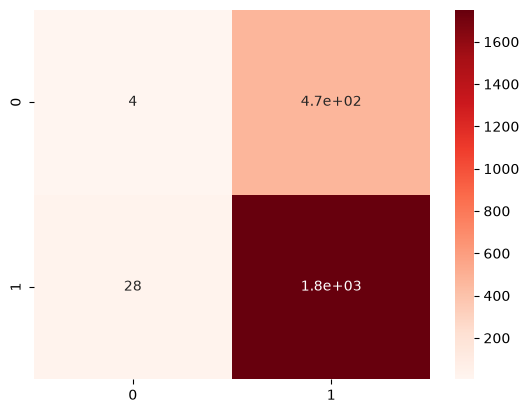

In [8]:
cm = confusion_matrix(Y_test, mnb.predict(X_test))
sns.heatmap(cm, annot=True, cmap="Reds")

## بخش د

مقایسه عملکرد مدل‌ها بر اساس ماتریس درهم‌ریختگی<br>
با بررسی و مقایسه ماتریس‌های درهم‌ریختگی، مدل رگرسیون لجستیکی عملکرد مناسب‌تر و قابل اعتمادتری نسبت به مدل بیز نشان می‌دهد.
<br>
دلایل برتری:<br>
تشخیص کلاس صفر (کلاس اقلیت): مدل بیز در شناسایی نمونه‌های کلاس صفر کاملاً ناموفق بوده و از بین حدود ۴۹۰ نمونه، تنها ۱ نمونه را به درستی تشخیص داده است. در مقابل، مدل رگرسیون لجستیکی موفق شده ۱۰۰ نمونه از کلاس صفر را به درستی شناسایی کند.<br>
جلوگیری از بایاس شدید: مدل بیز تقریباً تمام نمونه‌ها را به کلاس یک نسبت داده و دچار سوگیری شدید به سمت کلاس اکثریت شده است، در حالی که رگرسیون لجستیکی توانایی تفکیک بهتری میان هر دو کلاس ارائه می‌دهد.<br>
عملکرد مشابه در کلاس یک: هر دو مدل در تشخیص کلاس یک عملکرد نزدیکی دارند (حدود ۱۷۰۰ نمونه درست)، اما تفاوت اصلی و تعیین‌کننده در قدرت تشخیص کلاس صفر است.<br>
نتیجه‌گیری: به دلیل توازن بهتر و توانایی بالاتر در شناسایی هر دو کلاس، مدل رگرسیون لجستیکی به عنوان مدل برتر انتخاب می‌شود.

